# Subgrid Onset Variability Maps

This notebook reproduces the two-panel subgrid-variability map used as **Figure 14** in the paper.

- Panel (a): 1-degree variability vs nearest 4-degree onset
- Panel (b): 0.25-degree variability vs nearest 4-degree onset

## Workflow Overview

1. Load IMD rainfall at 1-degree, 0.25-degree, and 4-degree resolutions.
2. Compute observed onset dates for each year using the same MOK rule.
3. Reproject/align 0.25-degree rainfall and threshold to a common grid when requested.
4. Compute absolute day-difference maps against nearest 4-degree onset.
5. Average across years and render a two-panel map.

## Reproducibility Controls

- `use_cdo_025_rainfall`: switch between raw 0.25-degree rainfall and CDO-regridded rainfall.
- `use_author_025_grid`: enforce author-style 0.25-degree target grid (e.g., 6.625, 6.875, ...).
- `force_recompute`: bypass cache and recompute from raw files.

This notebook is intentionally execution-focused; reusable logic lives in `monsoonbench.spatial.subgrid_variability` and `monsoonbench.visualization.subgrid_variability`.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from monsoonbench.spatial import subgrid_variability as sv
from monsoonbench.utils.onset_timeseries import find_repo_root
from monsoonbench.visualization import subgrid_variability as viz_sub

In [2]:
repo_root = find_repo_root(Path.cwd())
data_dir = repo_root / "data"
out_dir = repo_root / "examples" / "demo_notebooks" / "outputs"
out_dir.mkdir(parents=True, exist_ok=True)
imd_1deg_dir = data_dir / "imd_rainfall_data" / "1p0"
imd_025deg_raw = data_dir / "imd_rainfall_data" / "0p25"
imd_025deg_cdo = data_dir / "imd_rainfall_data" / "0p25_cdo_6625"
imd_4deg_dir = data_dir / "imd_rainfall_data" / "4p0"
thres_1deg_file = data_dir / "imd_onset_threshold" / "mwset1x1.nc4"
thres_4deg_file = data_dir / "imd_onset_threshold" / "mwset4x4.nc4"

In [3]:
use_cdo_025_rainfall = True
imd_025deg_dir = imd_025deg_cdo if use_cdo_025_rainfall else imd_025deg_raw
thres_dir = data_dir / "imd_onset_threshold"
thres_025deg_file = sv.resolve_threshold_file(sorted(thres_dir.glob("mwset0*")))
shp_file = data_dir / "ind_map_shpfile" / "india_shapefile.shp"
years = list(range(1901, 2025))
force_recompute = False
mok = True
use_author_025_grid = True

In [4]:
mode_tag = "cdo025" if use_cdo_025_rainfall else "raw025"
cache_nc = out_dir / f"subgrid_variability_native4deg_author025grid_{mode_tag}.nc"
plot_png = out_dir / f"subgrid_variability_{mode_tag}.png"
compute_maps = sv.compute_mean_subgrid_variability_maps
r1, r025, r4 = imd_1deg_dir, imd_025deg_dir, imd_4deg_dir
t1, t4, t025 = thres_1deg_file, thres_4deg_file, thres_025deg_file

In [5]:
u25 = use_author_025_grid
frc = force_recompute
variability_ds = compute_maps(
    years, r1, r025, r4, t1, t4, t025, cache_nc, mok, u25, frc
)
print(variability_ds)

[1/124] Processing year 1901 ...
Loading IMD rainfall from: c:\Users\50573\Documents\AAASlashie\MSCAPP\2026-WINTER\DATA 27100\monsoon-bench\data\imd_rainfall_data\1p0\data_1901.nc
Renamed dimensions: {'LATITUDE': 'lat', 'LONGITUDE': 'lon', 'TIME': 'time'}
Loading IMD rainfall from: c:\Users\50573\Documents\AAASlashie\MSCAPP\2026-WINTER\DATA 27100\monsoon-bench\data\imd_rainfall_data\0p25_cdo_6625\1901.nc
Renamed dimensions: {'TIME': 'time'}
Loading IMD rainfall from: c:\Users\50573\Documents\AAASlashie\MSCAPP\2026-WINTER\DATA 27100\monsoon-bench\data\imd_rainfall_data\4p0\1901.nc
Renamed dimensions: {'TIME': 'time'}
Using MOK date (June 2nd) (1901-06-02) as start date for onset detection
Using MOK date (June 2nd) (1901-06-02) as start date for onset detection
  Regridded 0.25 threshold -> author 0.25 grid (66.625, 6.625)
Using MOK date (June 2nd) (1901-06-02) as start date for onset detection
[2/124] Processing year 1902 ...
Loading IMD rainfall from: c:\Users\50573\Documents\AAASlashi

## Plot and Diagnostics

## Note on Remaining Differences vs Paper Figure 14

Based on collaborator discussion, small residual differences in panel (b) (especially patch texture near the west coast and southern tip) are expected when 0.25-degree grids are not perfectly aligned.

### What was updated

- 4-degree onset is taken from the native repository 4-degree rainfall product.
- 0.25-degree threshold and 0.25-degree rainfall are aligned before onset detection.
- We support the author-style 0.25-degree target grid with 0.125-degree shift (e.g., 6.50 -> 6.625).

### Why differences can remain

- If raw 0.25-degree inputs are used, threshold/rainfall cell centers can be offset by 0.125 degrees.
- Nearest-neighbor-based alignment can leave local texture differences even when large-scale structure matches.
- The paper workflow used CDO regridding so each 0.25-degree cell nests cleanly inside the 4-degree parent cell.

### Practical recommendation

For closest paper match, use CDO-regridded 0.25-degree inputs (`use_cdo_025_rainfall=True`) together with author-grid forcing (`use_author_025_grid=True`).


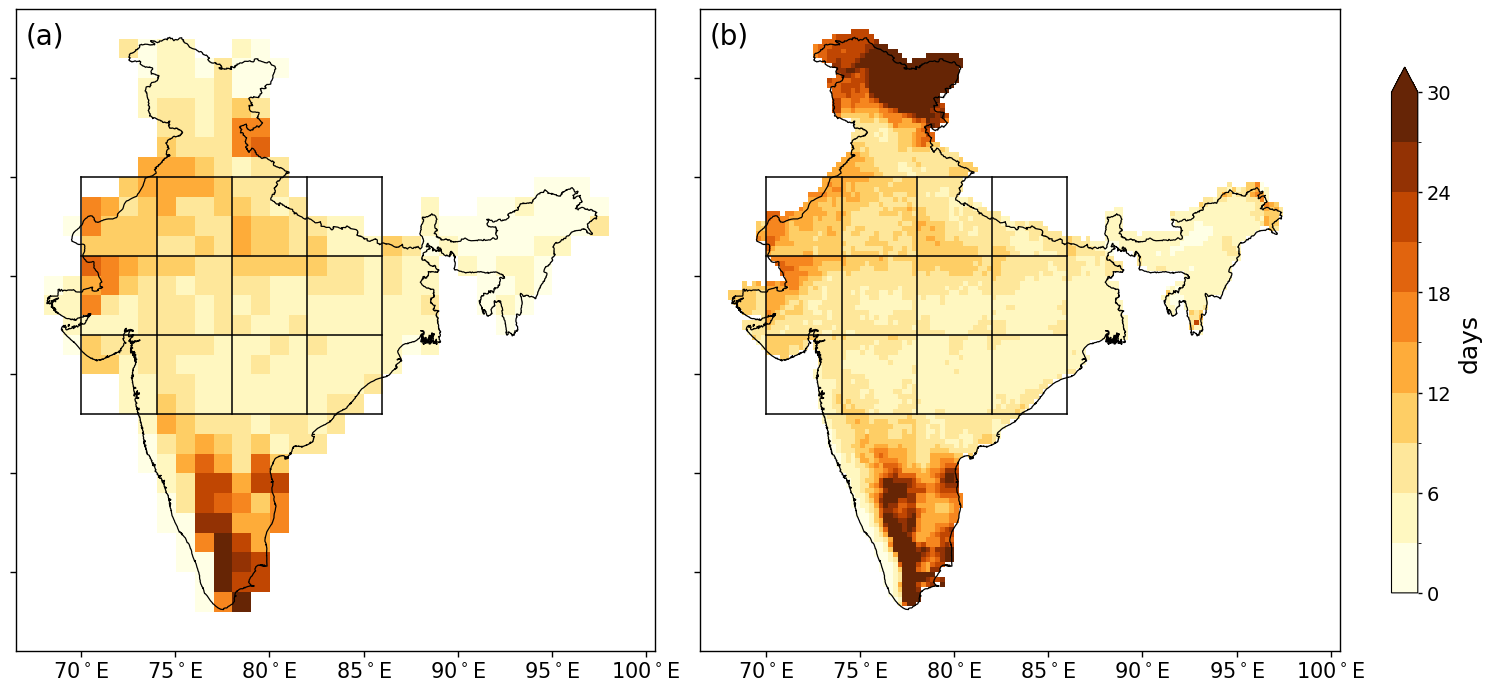

In [6]:
plot_maps = viz_sub.plot_subgrid_variability_map_pair
fig, axes = plot_maps(variability_ds, shp_file, plot_png)
a = variability_ds["panel_a_1deg"].values
b = variability_ds["panel_b_025deg"].values

In [7]:
print("Saved figure:", plot_png)
print("A:", float(np.nanmin(a)), float(np.nanmax(a)), int(np.isfinite(a).sum()))
print("B:", float(np.nanmin(b)), float(np.nanmax(b)), int(np.isfinite(b).sum()))
plt.show()

Saved figure: c:\Users\50573\Documents\AAASlashie\MSCAPP\2026-WINTER\DATA 27100\monsoon-bench\examples\demo_notebooks\outputs\subgrid_variability_cdo025.png
A: 0.0 63.62096774193548 357
B: 0.5 106.21774193548387 4964
